In [1]:
# IMPORT LIBARIES

In [103]:
# TO HANDLE THE DATA
import pandas as pd
import numpy as np
from scipy import stats
# TO VISUALIZE THE DATA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# TO PREPROCESS THE DATA
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer,KNNImputer
# IMPORT ITERATIVE IMPUTER
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# MACHINE LEARNING
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
# FOR CLASSIFICATION TASKS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier,RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_absolute_error,mean_squared_error,r2_score
# ignore warnings
import warnings
warnings.filterwarnings('ignore')



In [104]:
# LOAD DATASET
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
# print all column
pd.set_option('display.max_columns',None)
# print first 10 rows
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [105]:
# EDA

In [106]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

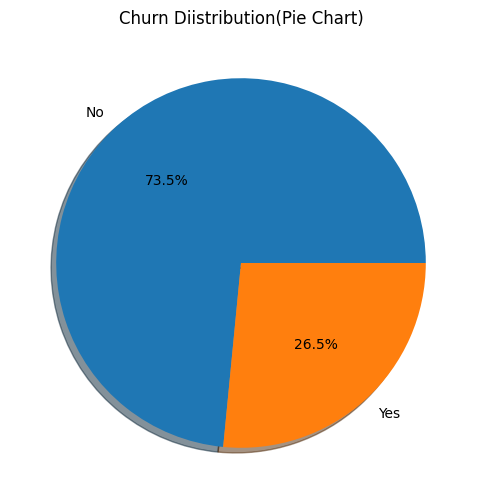

In [107]:
# count values

churn_counts=df['Churn'].value_counts()
# pie chart
plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    shadow=True
)
plt.title("Churn Diistribution(Pie Chart)")
plt.show()
                            

In [108]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [109]:
df[df['TotalCharges'].str.strip()==""][['customerID','TotalCharges']]

,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [110]:
# before
print("Before:",df['TotalCharges'].dtype)
# convert datatype for "total charges"
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
# after
print ("After:",df['TotalCharges'].dtype)

Before: object
After: float64


In [111]:
# check missing values:

In [112]:
print(df.isnull().sum().sort_values(ascending=False))

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64


In [113]:
# remove id column
df=df.drop(columns=['customerID'])
# removing missing values
df.dropna(inplace=True)

In [114]:
print(df.isnull().sum().sort_values(ascending=False))

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [115]:
# summary of mumerical columns

In [116]:
# summary dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [117]:
# CHECK UNIQUE VALUES

In [118]:
# apply loop check unique value without int or float in dataset

for col in df.columns:
    if df[col].dtype!='int64'and df[col].dtype!='float64':
        print(f'{col}:{df[col].unique()}')
    

gender:['Female' 'Male']
Partner:['Yes' 'No']
Dependents:['No' 'Yes']
PhoneService:['No' 'Yes']
MultipleLines:['No phone service' 'No' 'Yes']
InternetService:['DSL' 'Fiber optic' 'No']
OnlineSecurity:['No' 'Yes' 'No internet service']
OnlineBackup:['Yes' 'No' 'No internet service']
DeviceProtection:['No' 'Yes' 'No internet service']
TechSupport:['No' 'Yes' 'No internet service']
StreamingTV:['No' 'Yes' 'No internet service']
StreamingMovies:['No' 'Yes' 'No internet service']
Contract:['Month-to-month' 'One year' 'Two year']
PaperlessBilling:['Yes' 'No']
PaymentMethod:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn:['No' 'Yes']


In [119]:
# VISUALIZATION

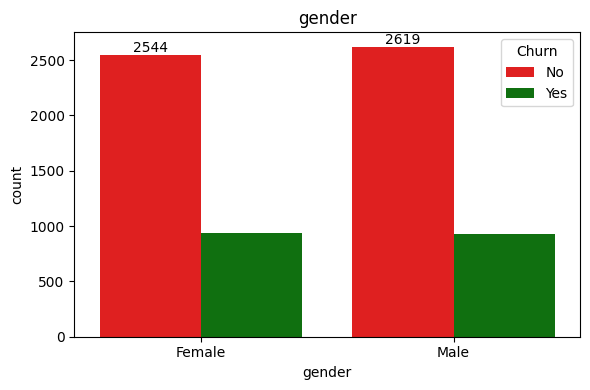

<Figure size 640x480 with 0 Axes>

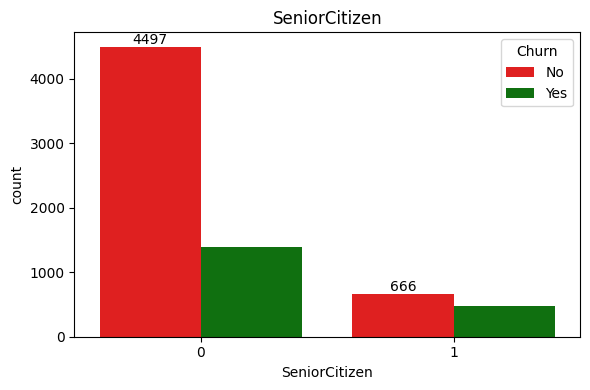

<Figure size 640x480 with 0 Axes>

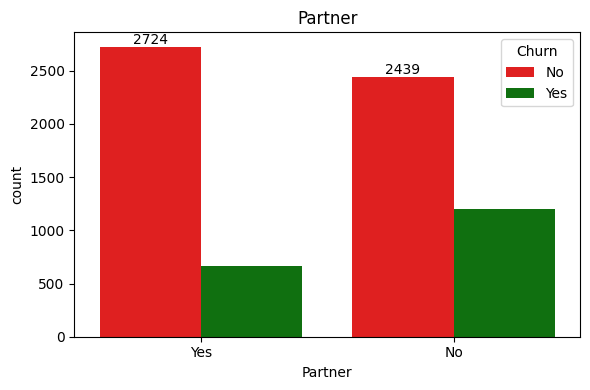

<Figure size 640x480 with 0 Axes>

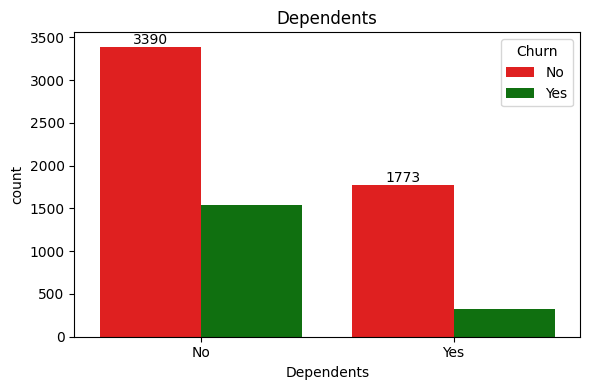

<Figure size 640x480 with 0 Axes>

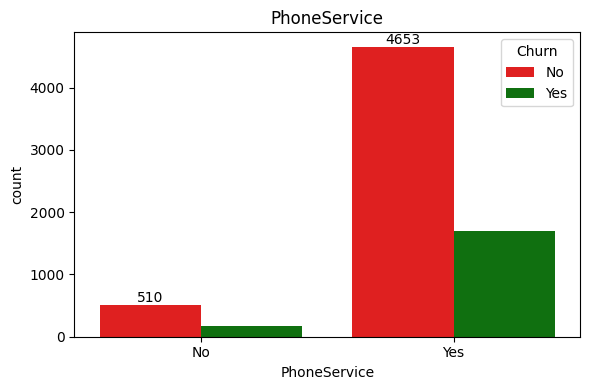

<Figure size 640x480 with 0 Axes>

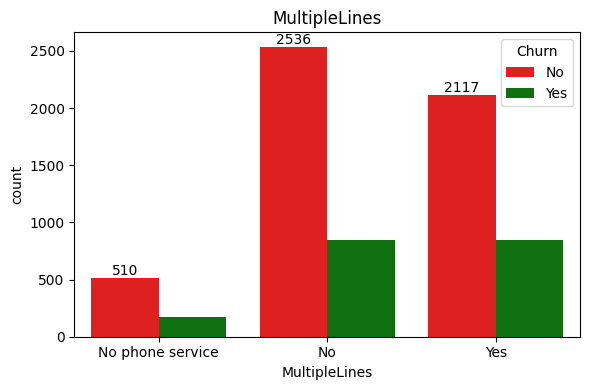

<Figure size 640x480 with 0 Axes>

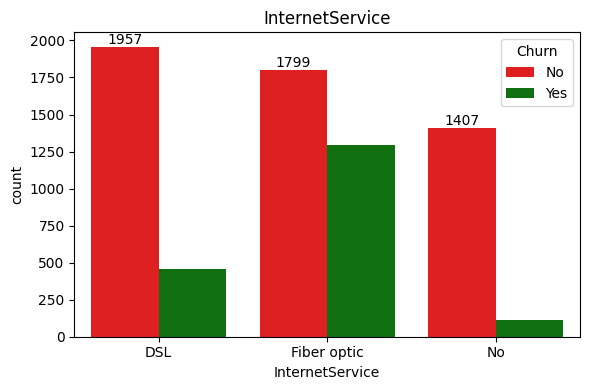

<Figure size 640x480 with 0 Axes>

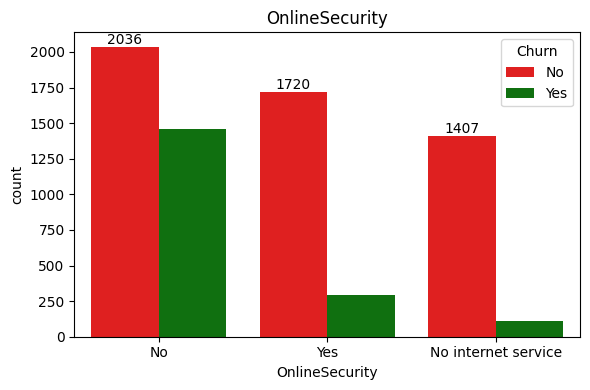

<Figure size 640x480 with 0 Axes>

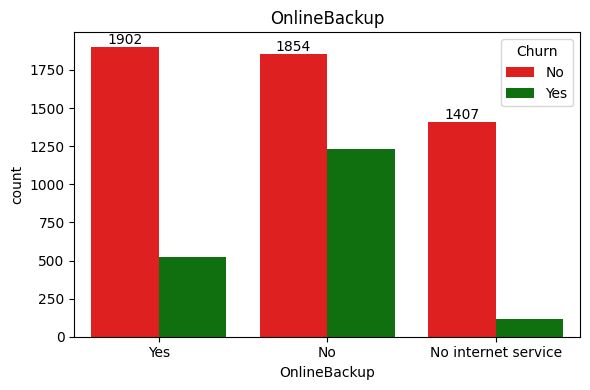

<Figure size 640x480 with 0 Axes>

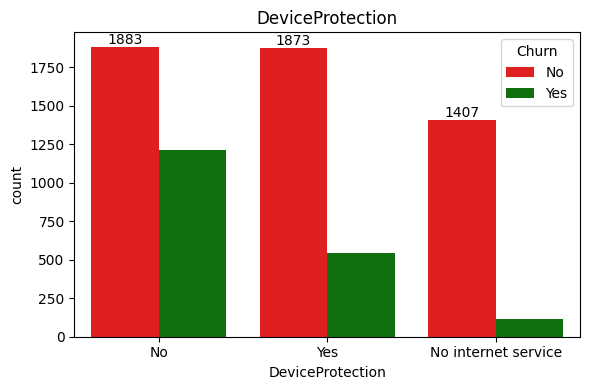

<Figure size 640x480 with 0 Axes>

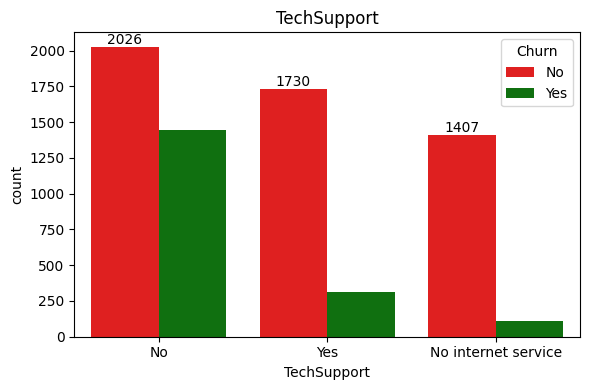

<Figure size 640x480 with 0 Axes>

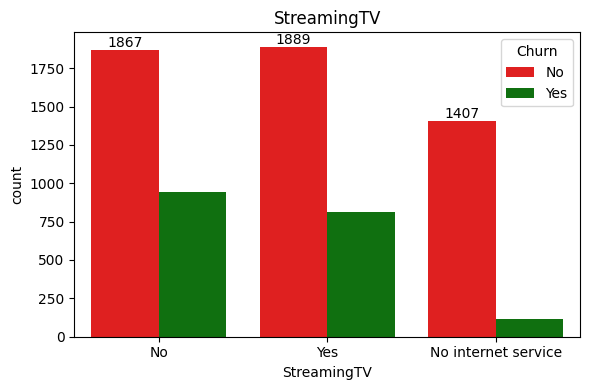

<Figure size 640x480 with 0 Axes>

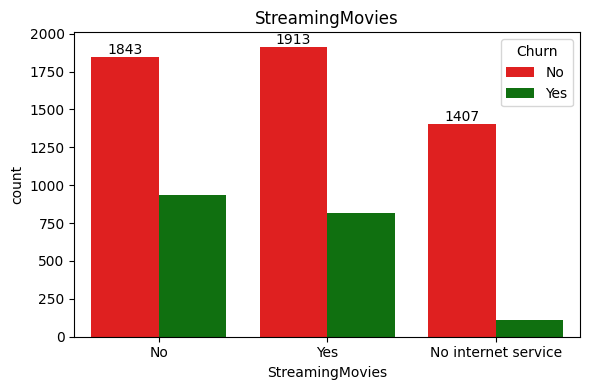

<Figure size 640x480 with 0 Axes>

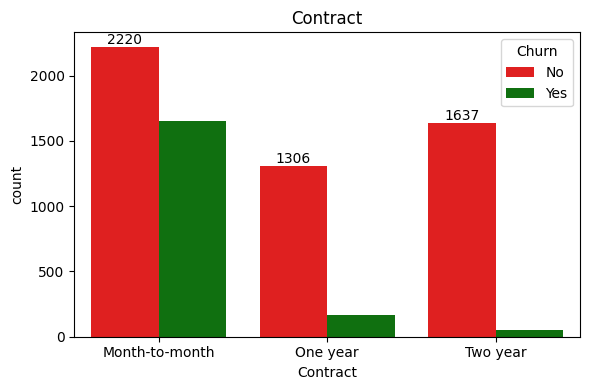

<Figure size 640x480 with 0 Axes>

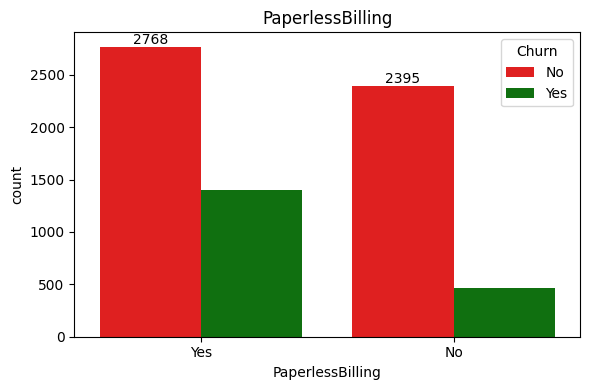

<Figure size 640x480 with 0 Axes>

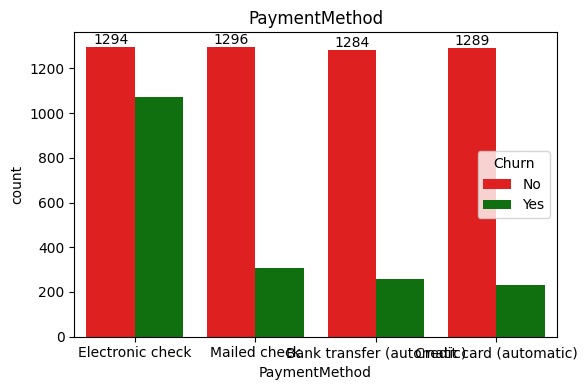

<Figure size 640x480 with 0 Axes>

In [120]:
# colors for yes and no

colors={'Yes':'green','No':'red'}
for i,predictor in enumerate(df.drop(columns=['Churn','TotalCharges','MonthlyCharges','tenure'])):
    plt.figure(i,figsize=(6,4))
    ax=sns.countplot(data=df,x=predictor,hue='Churn',palette=colors)
    plt.title(predictor)
    # Add values on top of each bar
    for container in ax.containers:
        ax.bar_label(container)
        plt.tight_layout()
        plt.show()

In [121]:
# NUMERICAL DATA

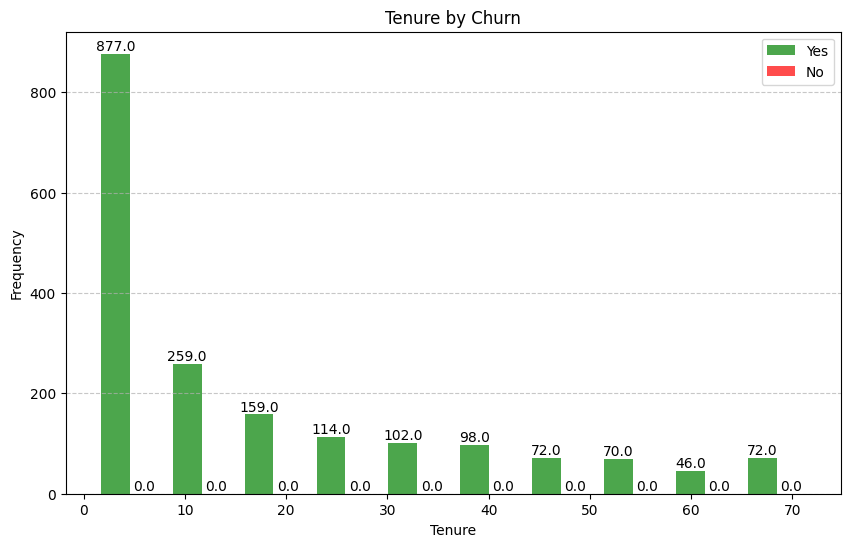

In [132]:
# make plot for tensure

churned=df[df['Churn']=='Yes']
not_churned=df[df['Churn']=='NO']

# plotting
plt.figure(figsize=(10,6))
plt.hist([churned['tenure'],not_churned['tenure']], 
         bins=10,  
         color=['green','red'],
         label=['Yes','No'],
         alpha=0.7)
    
          
plt.title('Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.7)
# add text on top of bars
for rect in plt.gca().patches:
    height=rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2,height,height,ha='center',va='bottom')


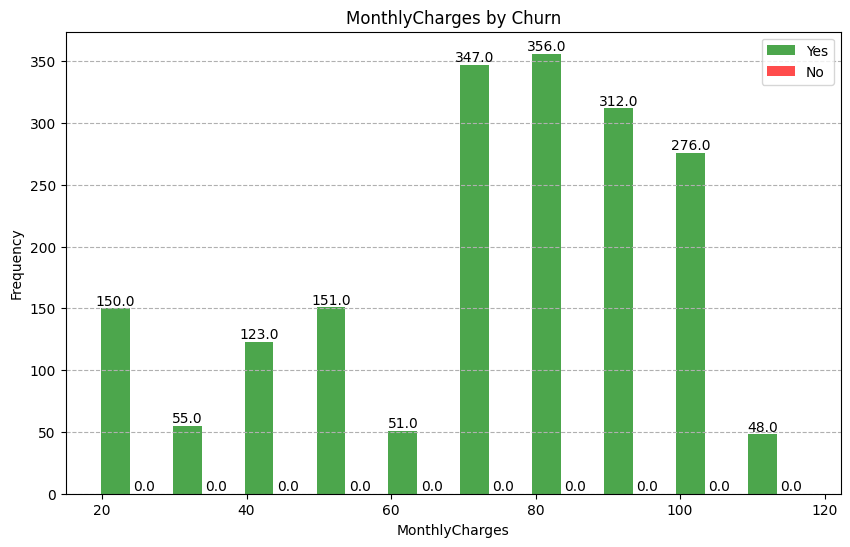

In [133]:
# make plot for monthly charges
churned=df[df['Churn']=='Yes']
not_churned=df[df['Churn']=='NO']
# plotting
plt.figure(figsize=(10,6))
plt.hist([churned['MonthlyCharges'],not_churned['MonthlyCharges']], 
          bins=10,
          color=['green','red'],
          label=['Yes','No'],
          alpha=0.7)

plt.title('MonthlyCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y',  linestyle='--')
# add text on top of bars
for rect in plt.gca().patches:
    height=rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width()/2,height,height,ha='center',va='bottom')

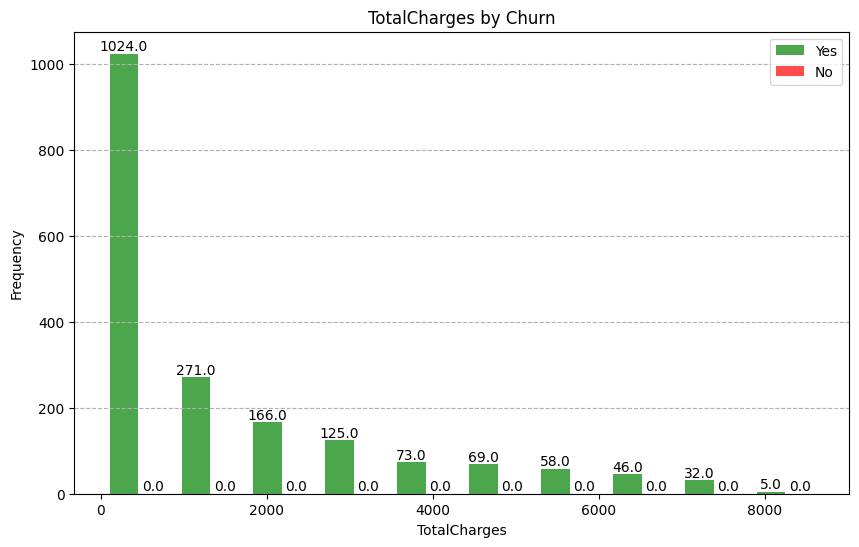

In [134]:
# make plot for tensure

churned=df[df['Churn']=='Yes']
not_churned=df[df['Churn']=='NO']
# plotting
plt.figure(figsize=(10,6))
plt.hist([churned['TotalCharges'], not_churned['TotalCharges']], bins=10,
         color=['green','red'],
         label=['Yes','No'],
         alpha=0.7)
plt.title('TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--')
# add text on top of bars
for rect in plt.gca().patches:
    height=rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width()/2,height,height,ha='center',va='bottom')

In [135]:
# MACHINE LEARNING

In [136]:
# encode target column 'Churn'using LabelEncoder

le=LabelEncoder()
df['Churn']=le.fit_transform(df['Churn'])

# identify categorical columns(excluding target)

categorical_cols=df.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# one-hot encode categorical features

df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)
numerical_cols=['tenure','MonthlyCharges','TotalCharges']

scaler=StandardScaler()
df[numerical_cols]=scaler.fit_transform(df[numerical_cols])

In [137]:
# split dataset into x and y

X=df.drop('Churn',axis=1)
y=df['Churn']
print("X shape:",X.shape)
print("y shape:",y.shape)
# data into train and split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    
          

X shape: (7032, 30)
y shape: (7032,)


In [53]:
# initialize an empty list to store model scores

model_scores=[]

# create a list of models to evaluate
models=[
    ('Random Forest',RandomForestClassifier(random_state=42),
     {'model__n_estimators':[50,100,200],
      'model__max_depth':[None,10,20]}),
    # add hyperparameters for ramdom forest
    ('Gradient Boosting',GradientBoostingClassifier(random_state=42),
     {'model__n_estimators':[50,100,200],
      'model__learning_rate':[0.05,0.1,0.5]}),
    # add hyperparameters for gradient boosting
    ('Support Vector Machine',SVC(random_state=42,class_weight='balanced'),
     {'model__C':[0.1,1,10],
      'model__gamma':['scale','auto']}),
     # add hyperparmeters for SVM
    ('Logistic Regression',LogisticRegression(random_state=42,class_weight='balanced'),
     {'model__C':[0.1,1,10],
      'model__penalty':['l1','l2']}),
    # add hyperparmeters for logistic regression
    ('K-Nearest Neighbors',KNeighborsClassifier(),
     {'model__n_neighbors':[3,5,7],
     'model__weights':['uniform','distance']}),
    # add hyperparameters for KNN
     ('Decision Tree',DecisionTreeClassifier(random_state=42),
      {'model__max_depth':[None,10,20],
       'model__min_samples_split':[2,5,10]}),
    # add hyperparameters for decision tree
    ('Ads Boost',AdaBoostClassifier(random_state=42),
      {'model__n_estimators':[50,100,200],
        'model__learning_rate':[0.05,0.1,0.5]}),
    # add hyperparameters for ada boost
     ('XGBoost',XGBClassifier(random_state=42),
       {'model__n_estimators':[50,100,200],
        'model__learning_rate':[0.05,0.1,0.5]}),
    # add hyperparameters for XG Boost
    ('Naive Bayes',GaussianNB(),{})
    # add hyperparameters for naive bayes
]
best_model=None
best_accuracy=0.0


# iterate over the models and evaluate their performance
for name,model,param_grid in models:
    # create a pipeline for each model
    pipeline=Pipeline([
        ('scaler',MinMaxScaler()),
        # feature scaling
        ('model',model)
    ])

    # hyperparameter tuning using gridsearchcv
    if param_grid:
        grid_search=GridSearchCV(pipeline,param_grid, cv=2)
        grid_search.fit(X_train, y_train)
        pipeline=grid_search.best_estimator_
        # fit the pipeline on the training data
        pipeline.fit(X_train,y_train)
        # make prediction oon the test data
        y_pred=pipeline.predict(X_test)
        # calculate accuracy score
        accuracy=accuracy_score(y_test,y_pred)
        # append model name and accuracy to the list
        model_scores.append({'Model':name,'Accuracy':accuracy})
        # convert the list to a dataframe
        scores_df=pd.DataFrame(model_scores)
        # print the performance metrics
        print("Model:",name)
        print("Test Accuracy:",  accuracy,"%")
        print()

        # check if the current model has the best accuracy
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_model=pipeline
            # retrieve the overall best model
            print("Best Model:")
            print("Test Accuracy:", best_accuracy)
            print("Model Pipeline:", best_model,"with accuracy",best_accuracy,"%")
           
                

Model: Random Forest
Test Accuracy: 0.7882018479033405 %

Best Model:
Test Accuracy: 0.7882018479033405
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))]) with accuracy 0.7882018479033405 %
Model: Gradient Boosting
Test Accuracy: 0.7981520966595593 %

Best Model:
Test Accuracy: 0.7981520966595593
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 GradientBoostingClassifier(n_estimators=50, random_state=42))]) with accuracy 0.7981520966595593 %
Model: Support Vector Machine
Test Accuracy: 0.7249466950959488 %

Model: Logistic Regression
Test Accuracy: 0.7263681592039801 %

Model: K-Nearest Neighbors
Test Accuracy: 0.7547974413646056 %

Model: Decision Tree
Test Accuracy: 0.749822316986496 %

Model: Ads Boost
Test Accuracy: 0.7953091684434968 %

Model: XGBoost
Test Accuracy: 0.8002842928216063 %

Best Model:
Test Accuracy: 0.8002